In [22]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [23]:

results_dir = Path("results")

Latency estimate: 0.000000818 s per message
Large-message bandwidth: 18427.11 MB/s


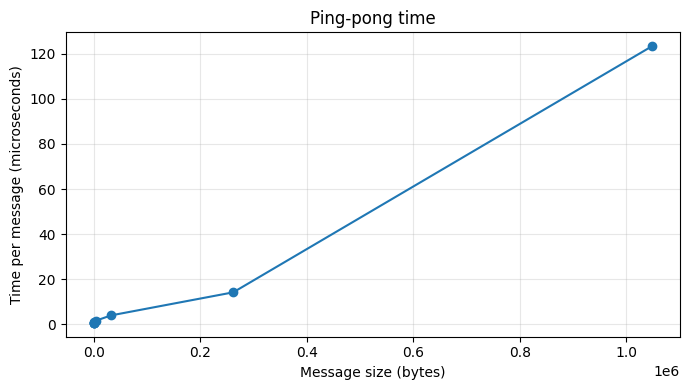

In [24]:
ping = pd.read_csv(results_dir / "ping_pong.csv")
latency = float(ping.loc[ping["size_bytes"] == 0, "time_per_message_seconds"].iloc[0])
large_bandwidth = float(ping["bandwidth_mb_s"].max())

print(f"Latency estimate: {latency:.9f} s per message")
print(f"Large-message bandwidth: {large_bandwidth:.2f} MB/s")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ping["size_bytes"], ping["time_per_message_seconds"] * 1_000_000, marker="o")
ax.set_xlabel("Message size (bytes)")
ax.set_ylabel("Time per message (microseconds)")
ax.set_title("Ping-pong time")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / "ping_pong_time.png")


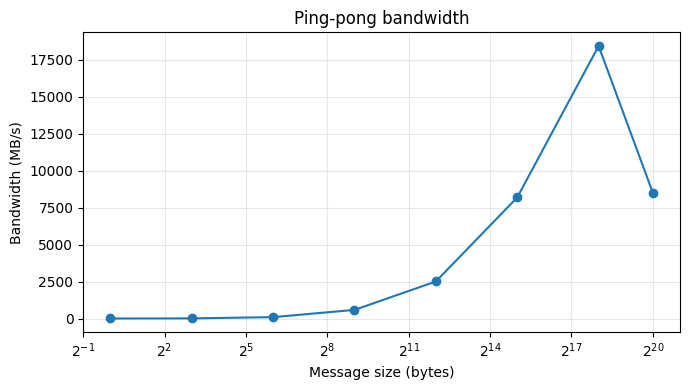

In [25]:
bandwidth = ping[ping["size_bytes"] > 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bandwidth["size_bytes"], bandwidth["bandwidth_mb_s"], marker="o")
ax.set_xscale("log", base=2)
ax.set_xlabel("Message size (bytes)")
ax.set_ylabel("Bandwidth (MB/s)")
ax.set_title("Ping-pong bandwidth")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / "ping_pong_bandwidth.png")


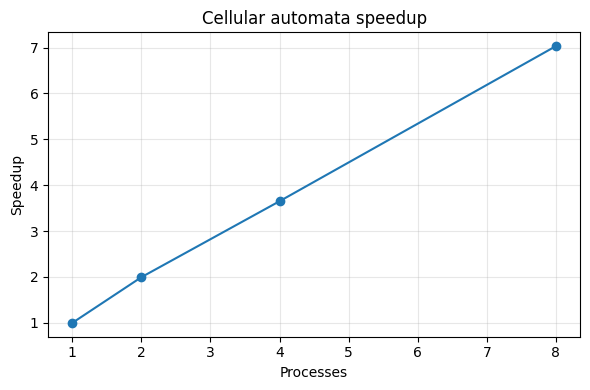

In [26]:
speedup = pd.read_csv(results_dir / "ca_speedup.csv")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(speedup["processes"], speedup["speedup"], marker="o")
ax.set_xlabel("Processes")
ax.set_ylabel("Speedup")
ax.set_title("Cellular automata speedup")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / "ca_speedup.png")


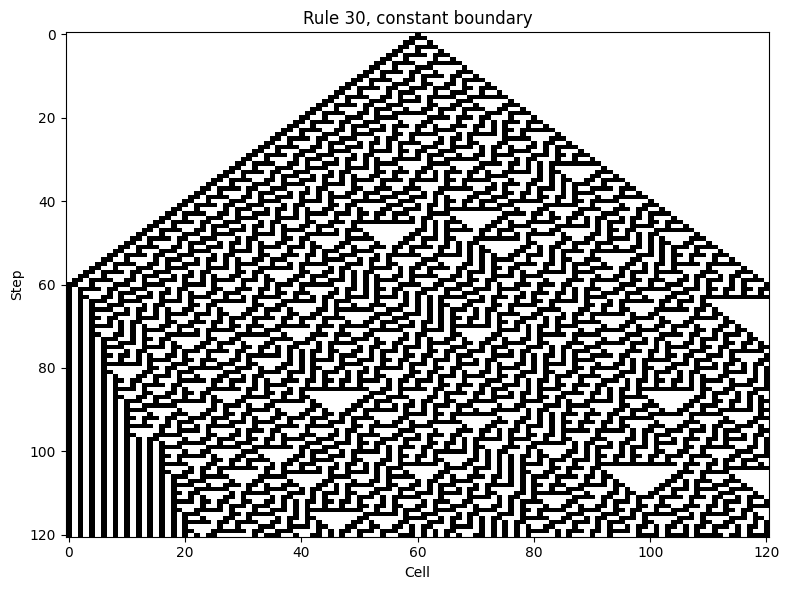

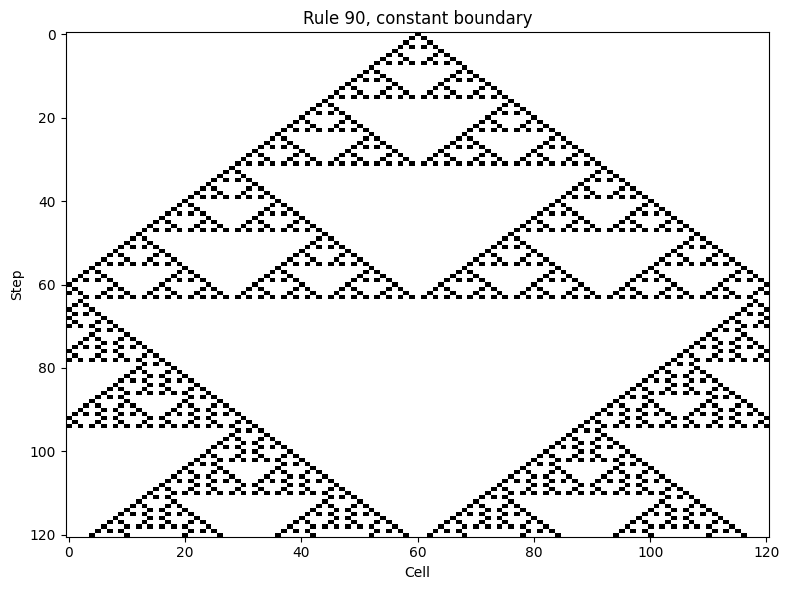

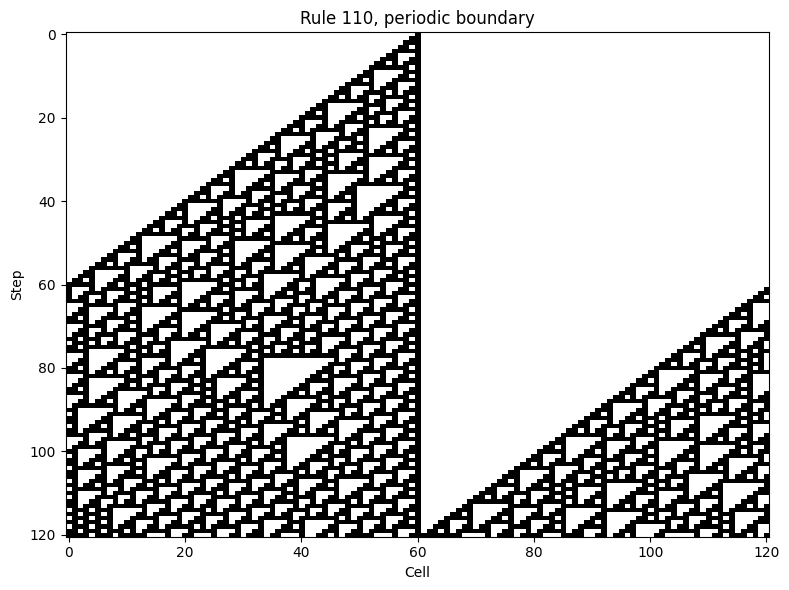

In [27]:
rule_plots = [
    ("ca_rule30_constant.csv", "ca_rule30_constant.png", "Rule 30, constant boundary"),
    ("ca_rule90_constant.csv", "ca_rule90_constant.png", "Rule 90, constant boundary"),
    ("ca_rule110_periodic.csv", "ca_rule110_periodic.png", "Rule 110, periodic boundary"),
]

for csv_name, svg_name, title in rule_plots:
    frame = pd.read_csv(results_dir / csv_name, header=None)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(frame.values, cmap="binary", interpolation="nearest", aspect="auto")
    ax.set_xlabel("Cell")
    ax.set_ylabel("Step")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(results_dir / svg_name)
